**Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("D:/Anaconda/Project/Sales Data Analysis Dashboard Project/data/Sales_Data_Analysis_Dataset_Realistic.csv")
df.head()

,Order_ID,Order_Date,Customer_ID,State,City,Category,Product,Quantity,Unit_Price,Discount_%,Sales,Profit,Payment_Method
0,100001,2024-11-23,CUST1279,Maharashtra,Mumbai,Electronics,Laptop,3,55000,5.0,156750.0,27833.59,UPI
1,100002,2023-01-28,CUST1287,Maharashtra,Mumbai,Home,Mixer,1,2800,0.0,2800.0,282.59,Card
2,100003,2023-06-13,CUST1216,Punjab,Ludhiana,Home,Mixer,4,2800,20.0,8960.0,1400.54,Cash
3,100004,2024-01-03,CUST1176,Gujarat,Ahmedabad,Clothing,T-Shirt,2,800,10.0,1440.0,283.03,Wallet
4,100005,2023-10-28,CUST1185,Gujarat,Surat,Clothing,T-Shirt,4,800,20.0,2560.0,810.54,Wallet


**Clean the Data**

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")
df = df.drop_duplicates()

if "order_date" in df.columns:
    df["order_date"] = pd.to_datetime(df["order_date"] , errors = "coerce")

df["sales"] = pd.to_numeric(df["sales"], errors = "coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors = "coerce")

df = df.dropna(subset=["sales"])
df.head()

,order_id,order_date,customer_id,state,city,category,product,quantity,unit_price,discount_%,sales,profit,payment_method
0,100001,2024-11-23,CUST1279,Maharashtra,Mumbai,Electronics,Laptop,3,55000,5.0,156750.0,27833.59,UPI
1,100002,2023-01-28,CUST1287,Maharashtra,Mumbai,Home,Mixer,1,2800,0.0,2800.0,282.59,Card
2,100003,2023-06-13,CUST1216,Punjab,Ludhiana,Home,Mixer,4,2800,20.0,8960.0,1400.54,Cash
3,100004,2024-01-03,CUST1176,Gujarat,Ahmedabad,Clothing,T-Shirt,2,800,10.0,1440.0,283.03,Wallet
4,100005,2023-10-28,CUST1185,Gujarat,Surat,Clothing,T-Shirt,4,800,20.0,2560.0,810.54,Wallet


**Basic Information About Table**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        5000 non-null   int64         
 1   order_date      5000 non-null   datetime64[ns]
 2   customer_id     5000 non-null   object        
 3   state           5000 non-null   object        
 4   city            4925 non-null   object        
 5   category        5000 non-null   object        
 6   product         5000 non-null   object        
 7   quantity        5000 non-null   int64         
 8   unit_price      5000 non-null   int64         
 9   discount_%      4925 non-null   float64       
 10  sales           5000 non-null   float64       
 11  profit          4925 non-null   float64       
 12  payment_method  4925 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(3), object(6)
memory usage: 546.9+ KB


**Key Performance Indicator**

In [5]:
total_sales = df["sales"].sum()
total_orders = df["order_id"].nunique() if "order_id" in df.columns else len(df)
average_order_value = total_sales / total_orders if total_orders else 0

print("Total Sales: ", total_sales)
print("Total Orders: ", total_orders)
print("Average Order Value: ", round(average_order_value, 2))

Total Sales:  114401800.0
Total Orders:  5000
Average Order Value:  22880.36


**Top Product**

In [6]:
top_products = df.groupby("product")["sales"].sum().sort_values(ascending=False).head(10)
top_products

product
Laptop      44891000.0
Sofa        27482500.0
Monitor     10395600.0
Desk         8159200.0
Cookware     5094450.0
Chair        4114075.0
Jacket       3816750.0
Mixer        3161480.0
Fan          2799280.0
Jeans        2007360.0
Name: sales, dtype: float64

**Top customers**

In [7]:
top_customers = df.groupby("customer_id")["sales"].sum().sort_values(ascending=False).head(10)
top_customers

customer_id
CUST1104    1020510.0
CUST1122     929110.0
CUST1171     919945.0
CUST1248     903480.0
CUST1208     897925.0
CUST1215     897900.0
CUST1099     894320.0
CUST1118     887655.0
CUST1177     881620.0
CUST1216     852595.0
Name: sales, dtype: float64

**Monthly Sales**

In [8]:
df["month"] = df["order_date"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("month")["sales"].sum().reset_index()
monthly_sales

,month,sales
0,2023-01,2806680.0
1,2023-02,3326725.0
2,2023-03,3550875.0
3,2023-04,4189170.0
4,2023-05,3727515.0
5,2023-06,3590115.0
6,2023-07,3247740.0
7,2023-08,4209770.0
8,2023-09,4270455.0
9,2023-10,4096370.0


**Create charts folder**

In [9]:
os.makedirs("charts", exist_ok=True)

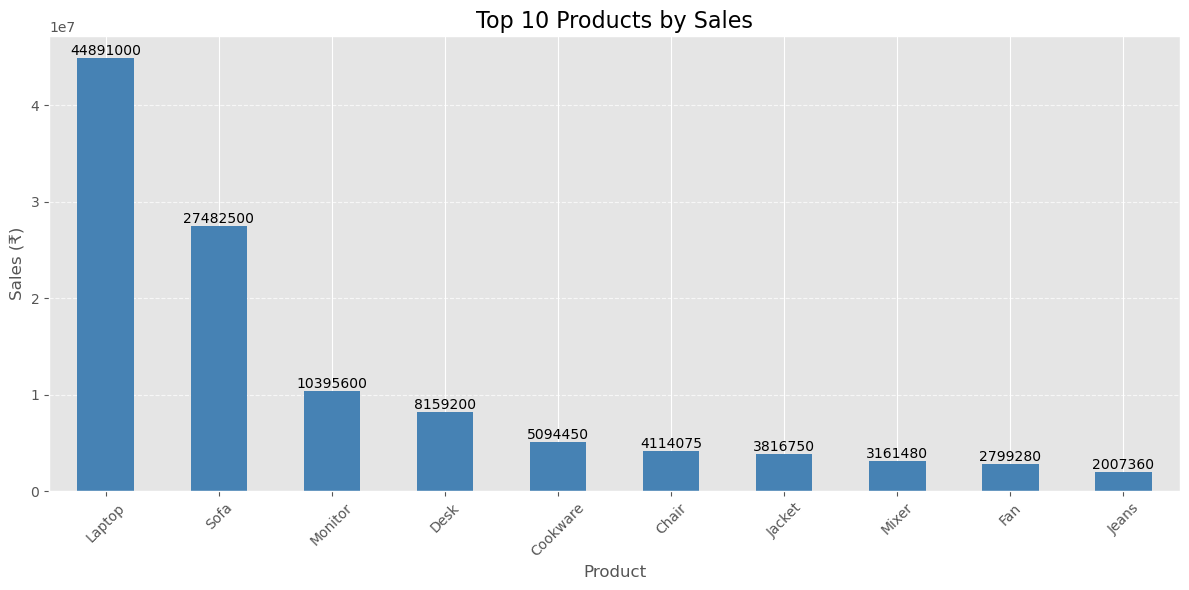

In [10]:
plt.figure(figsize=(12, 6))
ax = top_products.plot(kind="bar", figsize=(12, 6), color="steelblue")
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.title("Top 10 Products by Sales", fontsize=16)
plt.xlabel("Product", fontsize=12)
plt.ylabel("Sales (₹)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("D:/Anaconda/Project/Sales Data Analysis Dashboard Project/charts/top_products.png", dpi=300)
plt.show()

**Top Customers chart**

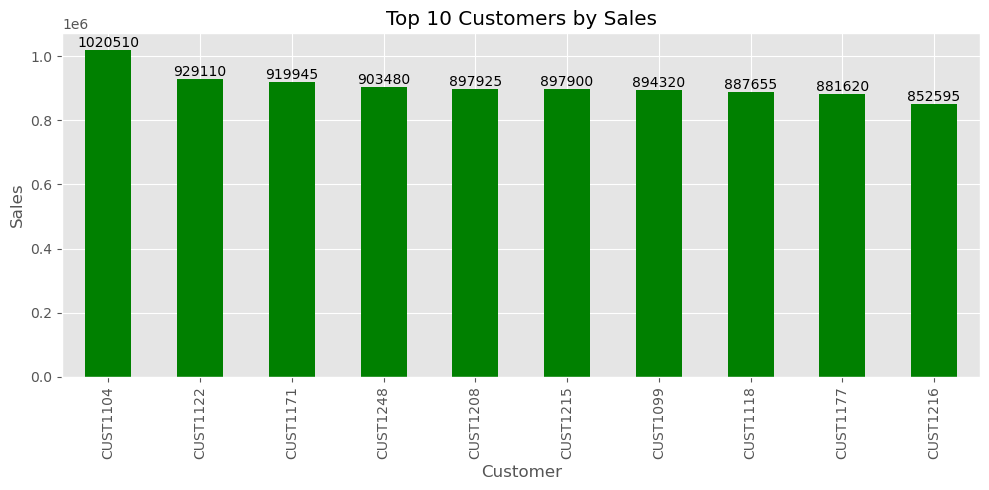

In [11]:
plt.figure(figsize=(10, 5))
ax = top_customers.plot(kind="bar", color="green", figsize=(10,5))
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("D:/Anaconda/Project/Sales Data Analysis Dashboard Project/charts/top_customers.png")
plt.show()

**Summary table**

In [12]:
summary = pd.DataFrame({
    "Metric": ["Total Sales", "Total Orders", "Average Order Value"],
    "Value": [total_sales, total_orders, round(average_order_value, 2)]
})

summary

,Metric,Value
0,Total Sales,1.144018e+08
1,Total Orders,5.000000e+03
2,Average Order Value,2.288036e+04
